In [1]:
print("Colab is working!")

Colab is working!


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic = pd.read_csv(url)

print(titanic.shape)

(891, 12)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic = pd.read_csv(url)

print("Dataset Shape:", titanic.shape)
titanic.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Missing Values:")
print(titanic.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
data = titanic[
    ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
].copy()

data["Age"] = data["Age"].fillna(data["Age"].median())

data["Sex"] = data["Sex"].map({
    "male": 0,
    "female": 1
})

X = data[
    ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
]

y = data["Survived"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (891, 6)
Target: (891,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[95 15]
 [20 49]]


In [10]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



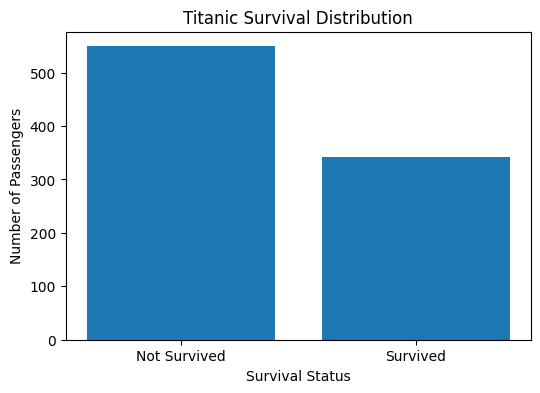

In [11]:
survival_count = titanic["Survived"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["Not Survived", "Survived"],
    survival_count.values
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

## Conclusion

Successfully performed data preprocessing, exploratory data analysis, and classification on the Titanic dataset.

Missing values were handled and categorical data was converted into numerical form. Logistic Regression was used to predict passenger survival and evaluated using accuracy, confusion matrix, and classification report.

Dataset Shape: (891, 12)

========== Model Performance ==========
Accuracy: 0.8044692737430168

Confusion Matrix:
[[95 15]
 [20 49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



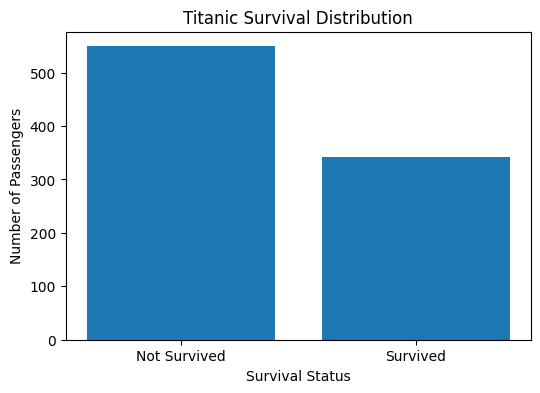


Post-Lab Completed Successfully


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

print("Dataset Shape:", titanic.shape)

# Select required columns
data = titanic[
    ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
].copy()

# Handle missing values
data["Age"] = data["Age"].fillna(data["Age"].median())

# Convert categorical variable
data["Sex"] = data["Sex"].map({
    "male": 0,
    "female": 1
})

# Features and target
X = data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
y = data["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n========== Model Performance ==========")
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization
survival_count = titanic["Survived"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    ["Not Survived", "Survived"],
    survival_count.values
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

print("\nPost-Lab Completed Successfully")